# Étape 1 — Préparation, nettoyage et enrichissement des données

L’objectif de cette étape est de construire un jeu de données propre, fusionné et enrichi pour entraîner un modèle de scoring crédit.

Le projet utilise les données Home Credit, composées de plusieurs fichiers décrivant :
- les demandes de crédit principales ;
- l’historique des crédits externes ;
- les anciennes demandes de crédit ;
- les paiements passés ;
- les historiques POS/Cash ;
- les cartes de crédit précédentes.

Les tables secondaires contiennent plusieurs lignes par client. Elles ont donc été agrégées au niveau `SK_ID_CURR` avant la fusion finale.

In [12]:
import pandas as pd
from IPython.display import Image, display

In [13]:
raw_summary = pd.read_csv("../reports/data_quality/raw_tables_summary.csv")
raw_summary

,table,rows,columns,duplicates,total_missing_values,missing_rate,numeric_columns,categorical_columns
0,application_train,307511,122,0,9152465,0.2440,106,16
1,application_test,48744,121,0,1404419,0.2381,105,16
2,bureau,1716428,17,0,3939947,0.1350,14,3
3,bureau_balance,27299925,3,0,0,0.0000,2,1
4,previous_application,1670214,37,0,11109336,0.1798,21,16
5,pos_cash_balance,10001358,8,0,52158,0.0007,7,1
6,installments_payments,13605401,8,0,5810,0.0001,8,0
7,credit_card_balance,3840312,23,0,5877356,0.0665,22,1
8,columns_description,219,5,0,133,0.1215,1,4
9,sample_submission,48744,2,0,0,0.0000,2,0


Les fichiers bruts présentent des volumes très différents. Certaines tables contiennent plusieurs millions de lignes, notamment `bureau_balance`, `installments_payments` et `POS_CASH_balance`.

Aucun doublon strict n’a été détecté dans les fichiers analysés. En revanche, plusieurs tables présentent des valeurs manquantes importantes, ce qui justifie une analyse spécifique avant la modélisation.

In [14]:

keys_summary = pd.read_csv("../reports/data_quality/keys_summary.csv")
keys_summary

,table,key,key_exists,rows,unique_keys,missing_keys,duplicated_key_rows,max_rows_per_key,mean_rows_per_key
0,application_train,SK_ID_CURR,True,307511,307511,0,0,1,1.00
1,application_test,SK_ID_CURR,True,48744,48744,0,0,1,1.00
2,bureau,SK_ID_CURR,True,1716428,305811,0,1410617,116,5.61
3,bureau,SK_ID_BUREAU,True,1716428,1716428,0,0,1,1.00
4,bureau_balance,SK_ID_BUREAU,True,27299925,817395,0,26482530,97,33.40
5,previous_application,SK_ID_CURR,True,1670214,338857,0,1331357,77,4.93
6,previous_application,SK_ID_PREV,True,1670214,1670214,0,0,1,1.00
7,pos_cash_balance,SK_ID_CURR,True,10001358,337252,0,9664106,295,29.66
8,pos_cash_balance,SK_ID_PREV,True,10001358,936325,0,9065033,96,10.68
9,installments_payments,SK_ID_CURR,True,13605401,339587,0,13265814,372,40.06


In [15]:
relations_summary = pd.read_csv("../reports/data_quality/relations_summary.csv")
relations_summary

,parent_table,child_table,key,parent_unique_keys,child_unique_keys,common_keys,parent_only_keys,child_only_keys,mean_child_rows_per_key,max_child_rows_per_key
0,application_train,bureau,SK_ID_CURR,307511,305811,263491,44020,42320,5.61,116
1,bureau,bureau_balance,SK_ID_BUREAU,1716428,817395,774354,942074,43041,33.40,97
2,application_train,previous_application,SK_ID_CURR,307511,338857,291057,16454,47800,4.93,77
3,application_train,pos_cash_balance,SK_ID_CURR,307511,337252,289444,18067,47808,29.66,295
4,application_train,installments_payments,SK_ID_CURR,307511,339587,291643,15868,47944,40.06,372
5,application_train,credit_card_balance,SK_ID_CURR,307511,103558,86905,220606,16653,37.08,192


L’analyse des clés montre que `application_train` et `application_test` contiennent une seule ligne par client, identifiée par `SK_ID_CURR`.

Les tables secondaires contiennent plusieurs lignes par client. Elles ne peuvent donc pas être fusionnées directement avec la table principale, car cela créerait des duplications de clients. Pour éviter ce problème, chaque table secondaire a été agrégée au niveau `SK_ID_CURR`.

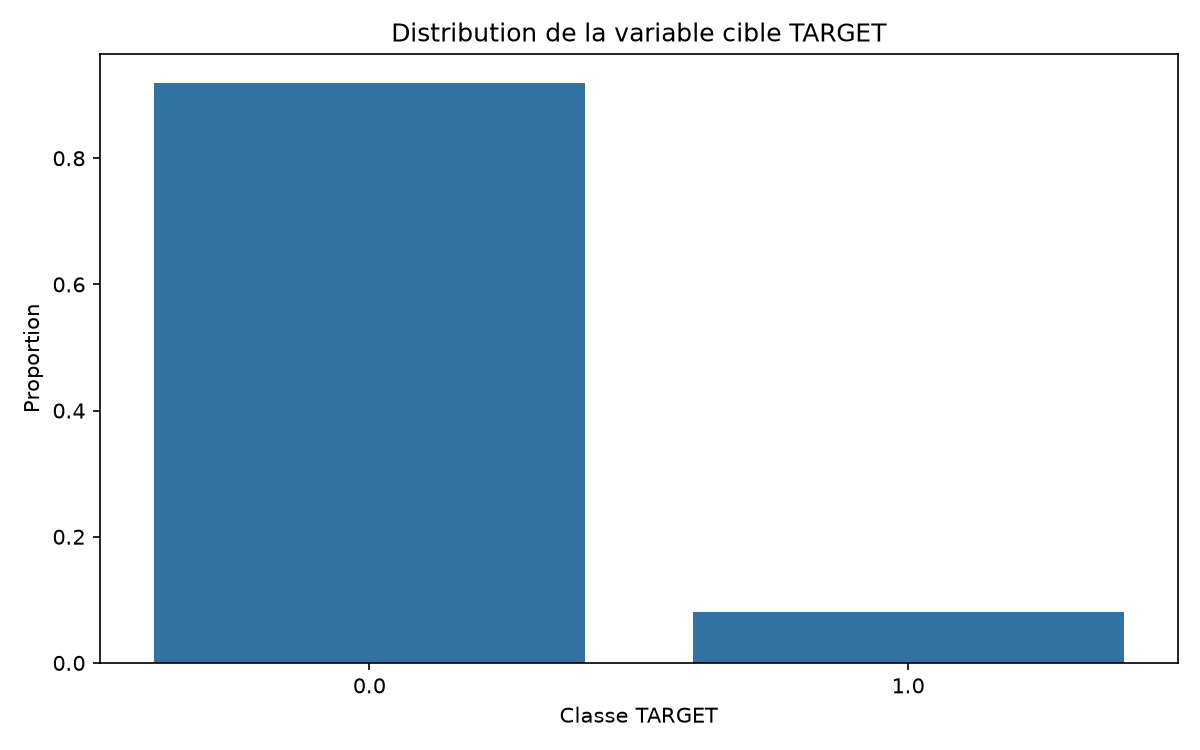

In [16]:
display(Image("../reports/figures/step1_target_distribution.png"))

La variable cible est fortement déséquilibrée : environ 92 % des clients appartiennent à la classe 0, contre environ 8 % à la classe 1.

Ce déséquilibre est un point majeur du projet, car le modèle pourrait être tenté de prédire majoritairement la classe dominante. Il faudra donc utiliser des métriques adaptées, notamment le recall, l’AUC et un score métier prenant en compte le coût plus élevé des faux négatifs.

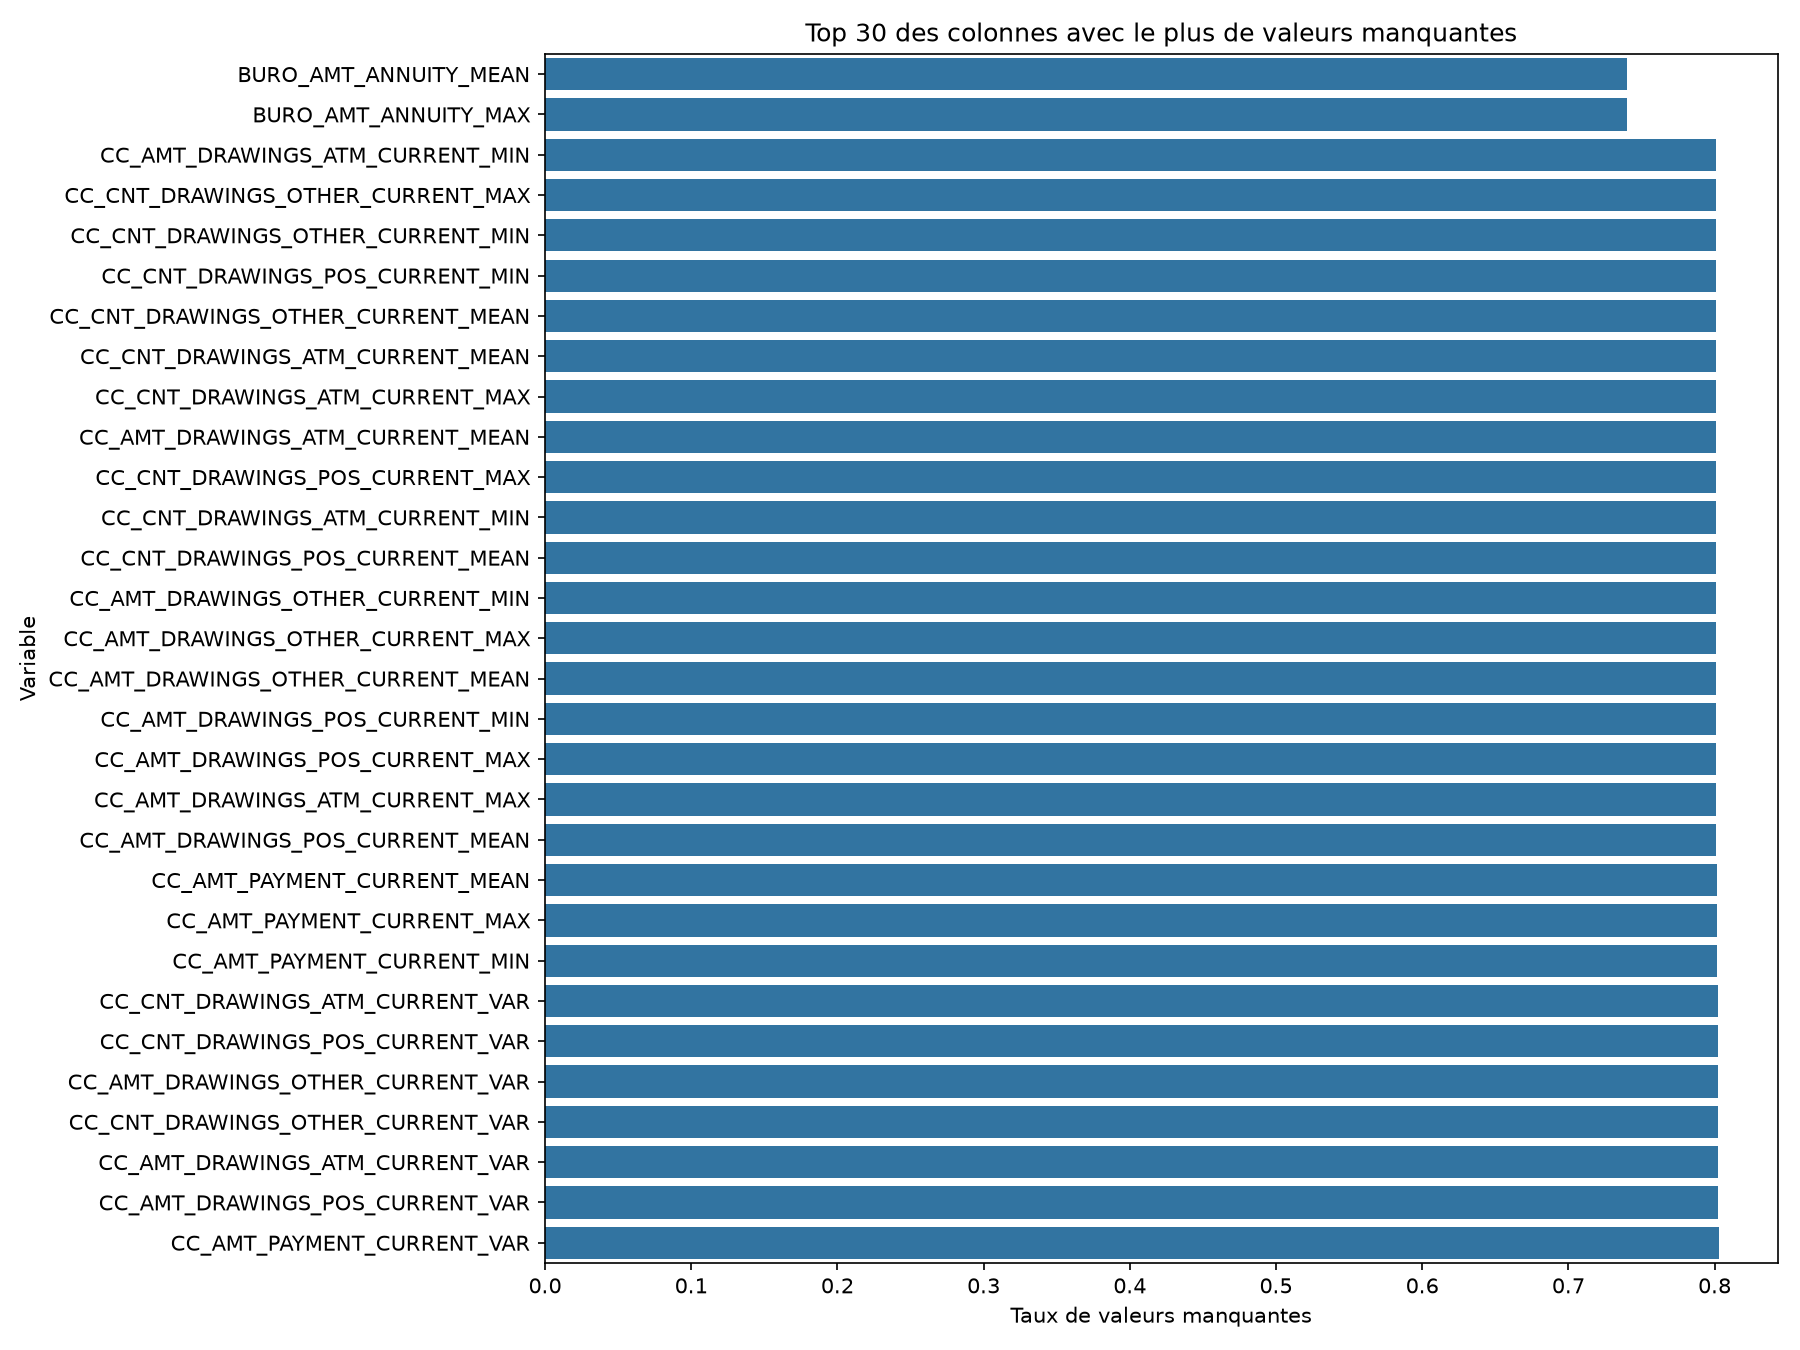

In [17]:
display(Image("../reports/figures/step1_missing_values_top30.png"))

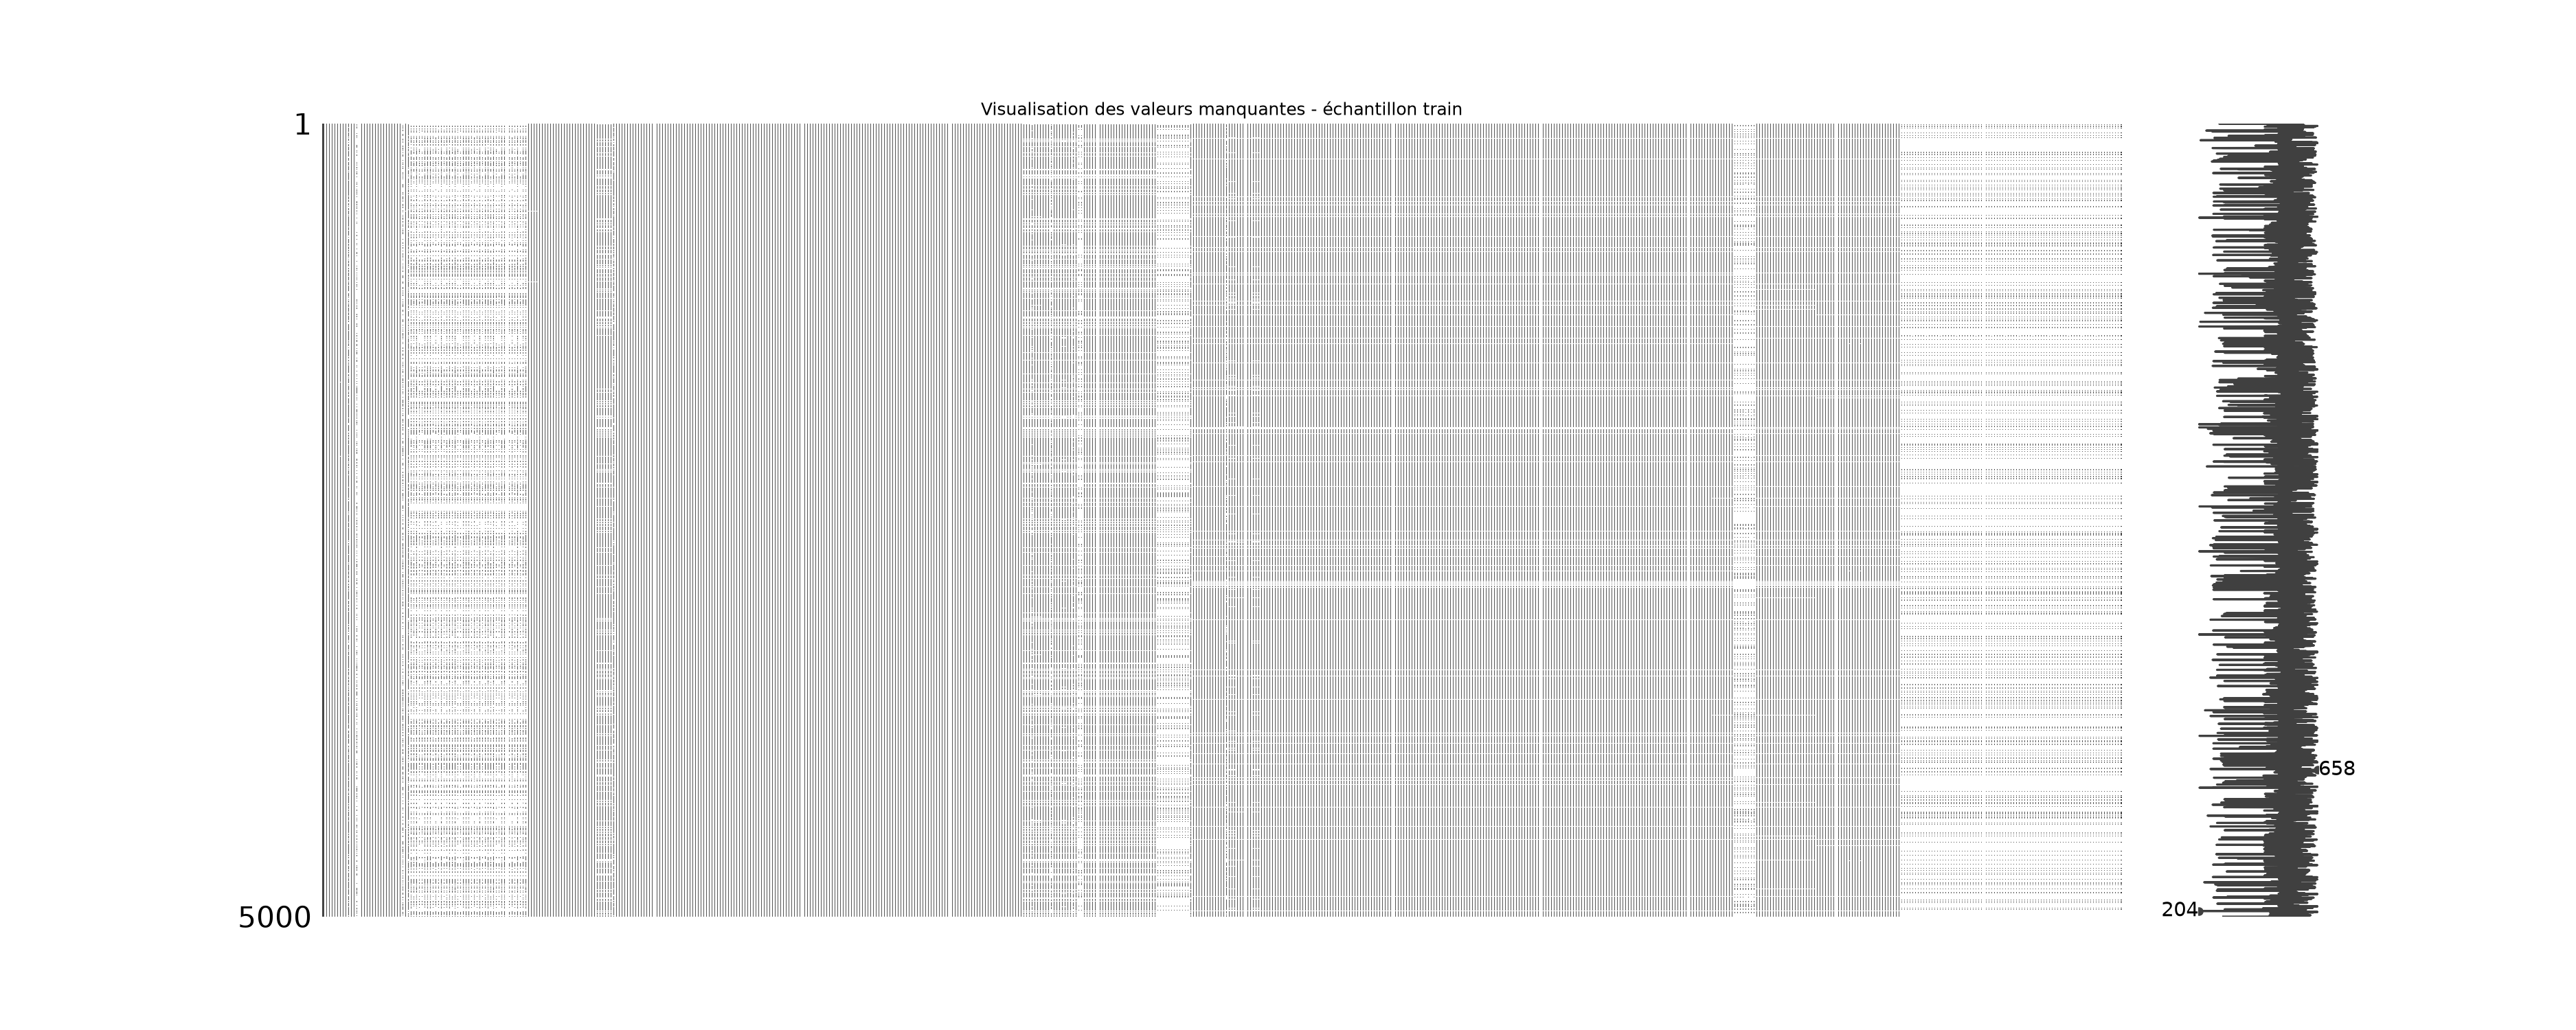

In [18]:
display(Image("../reports/figures/step1_missingno_matrix_train_sample.png"))

L’analyse des valeurs manquantes montre que certaines variables, notamment issues de l’historique des cartes de crédit, sont très incomplètes.

Les colonnes présentant plus de 80 % de valeurs manquantes ont été identifiées et documentées. Les colonnes constantes ont également été supprimées, car elles n’apportent aucune information au modèle.

L’imputation complète n’a pas été réalisée à cette étape afin d’éviter les fuites de données. Elle sera intégrée plus tard dans les pipelines de modélisation, avec un ajustement uniquement sur les données d’entraînement.

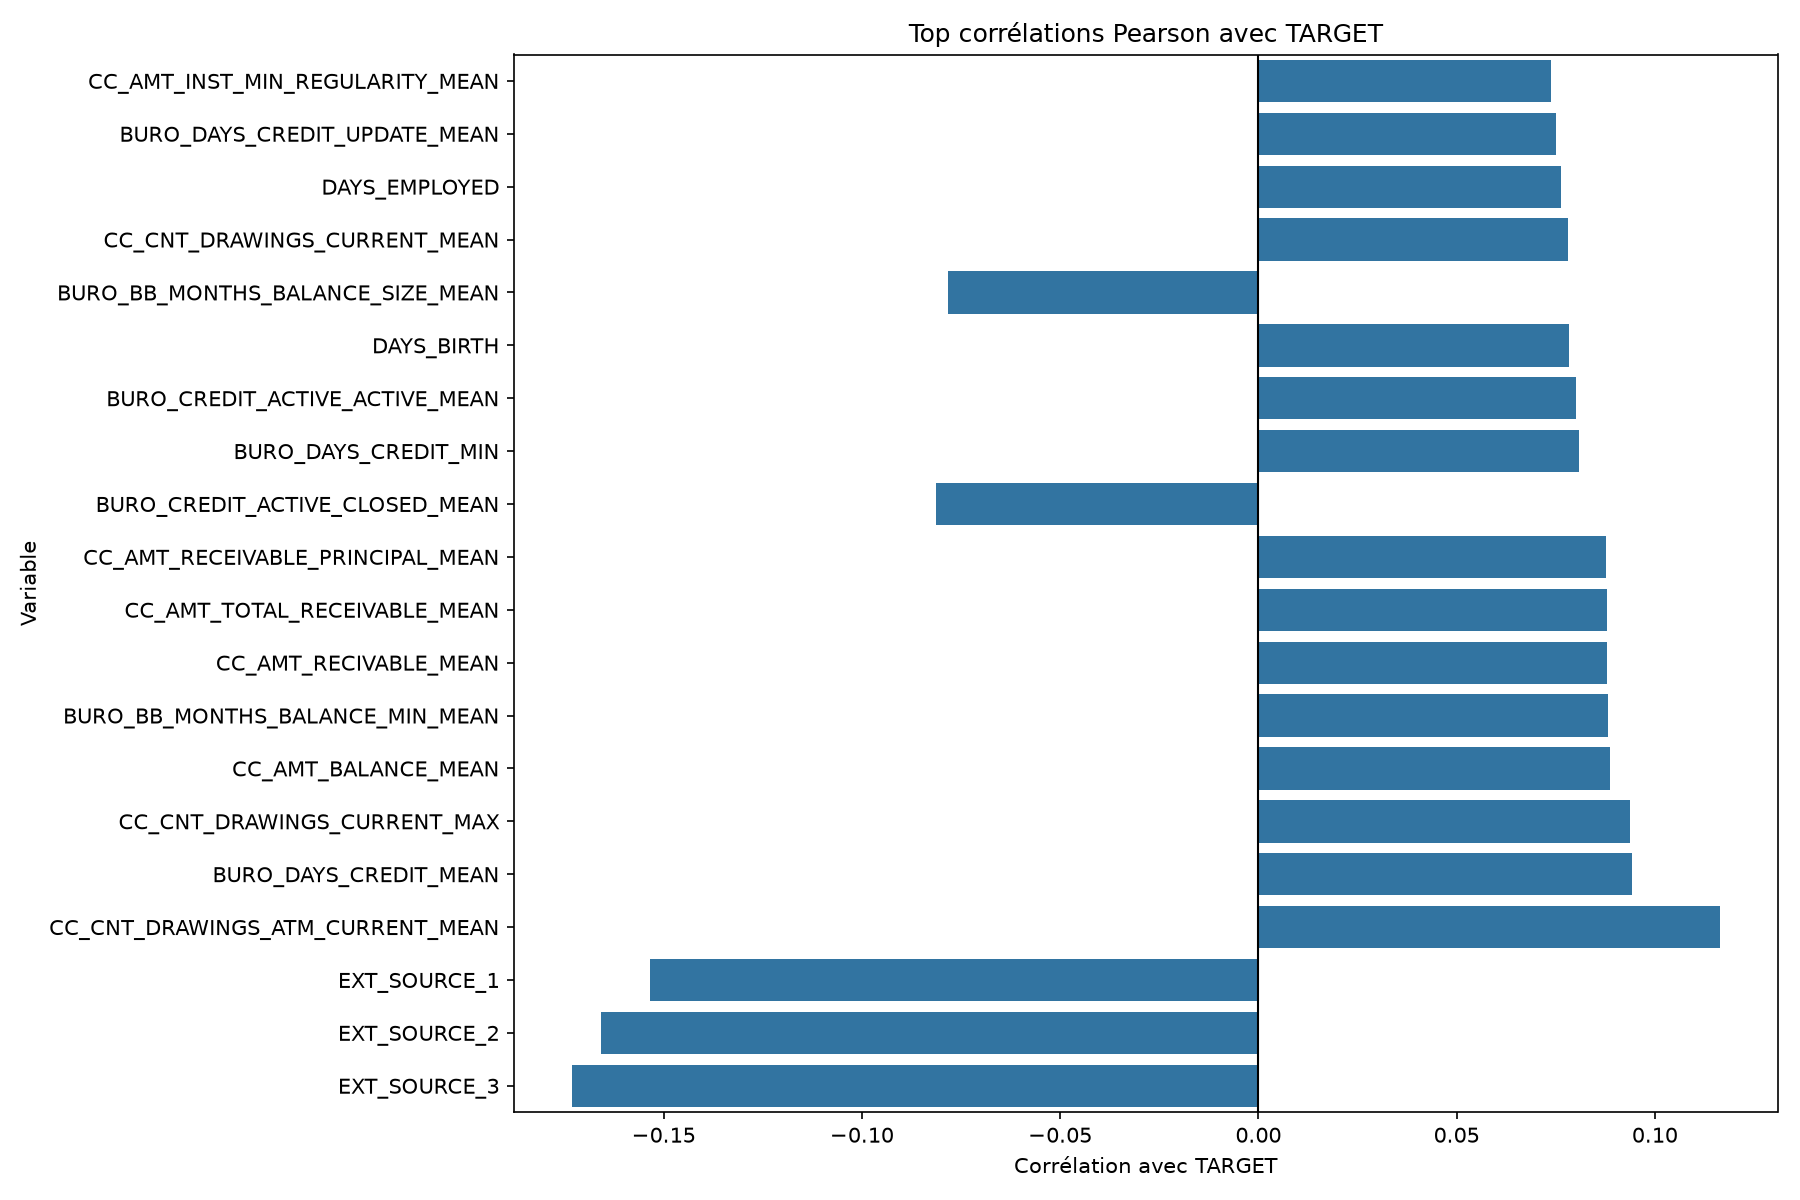

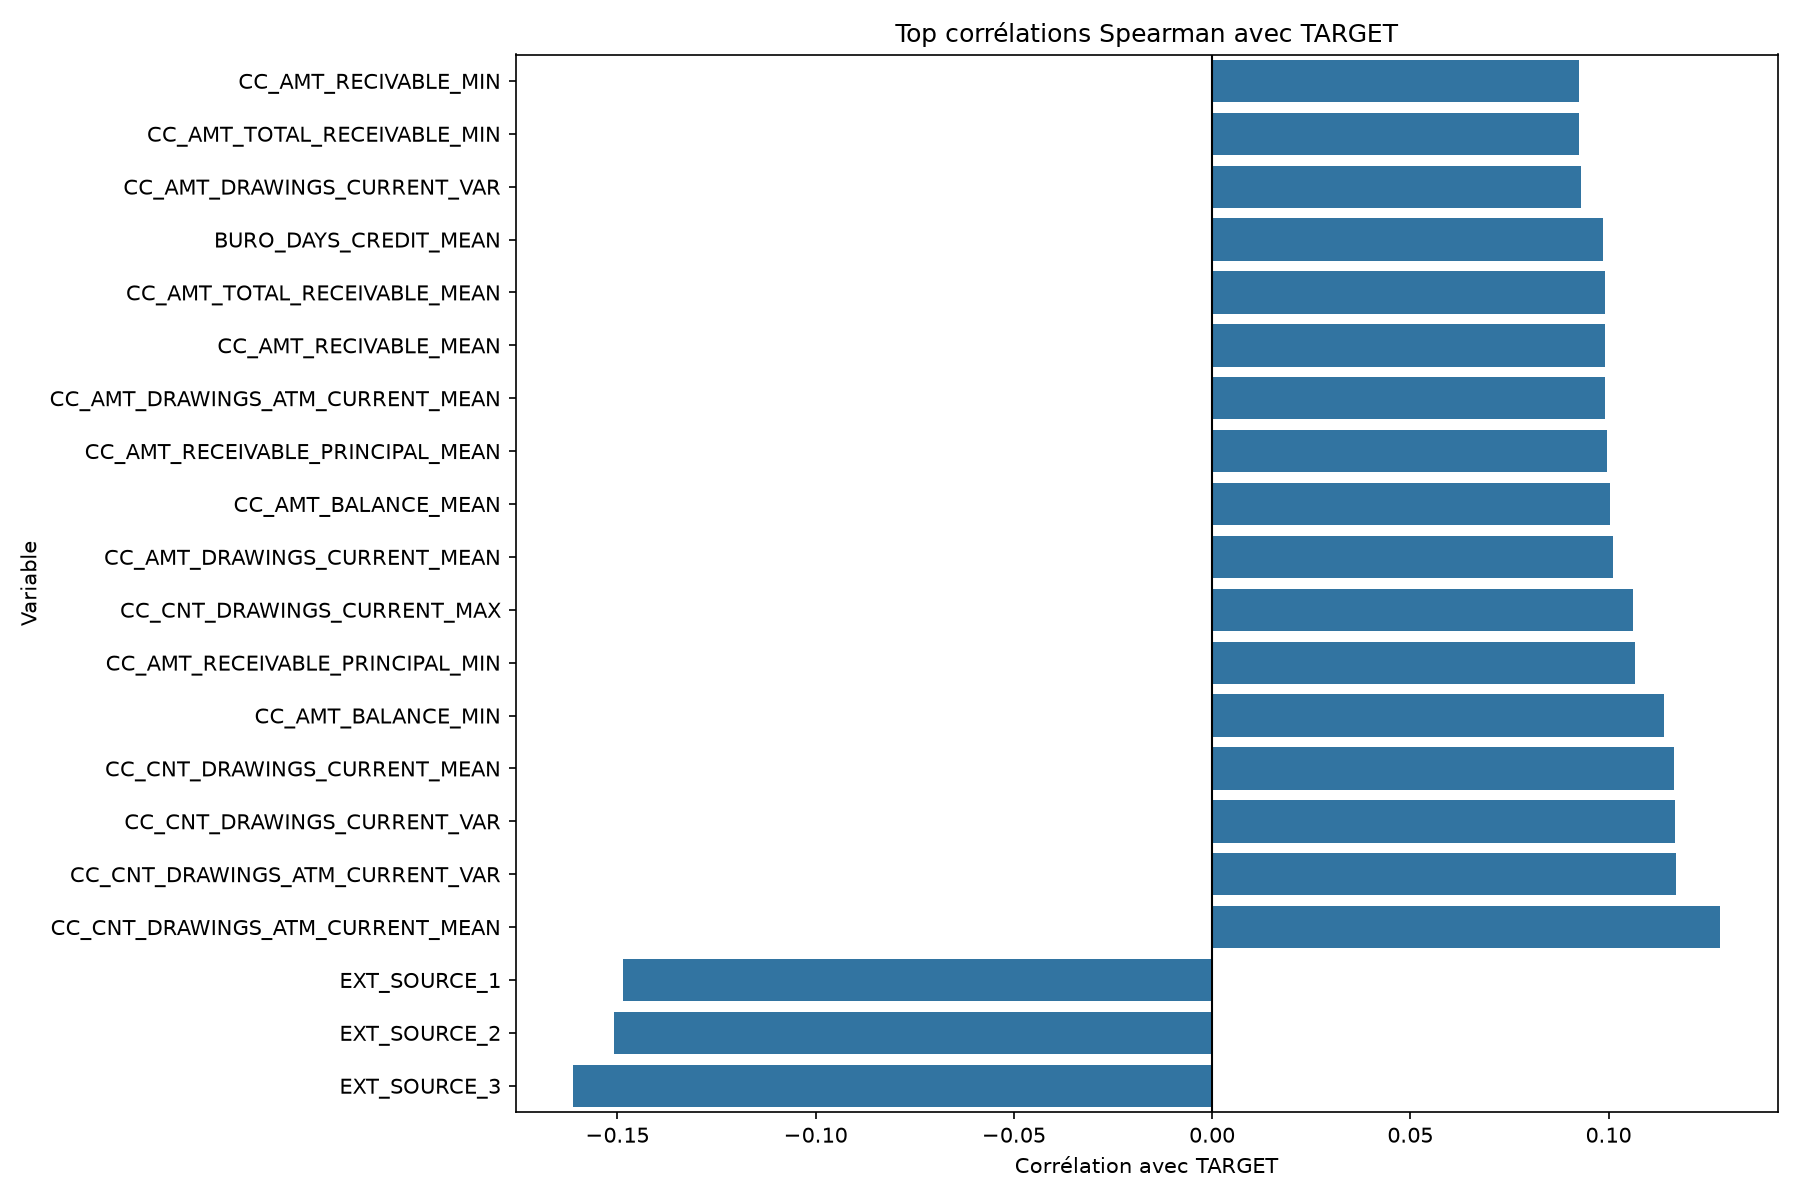

In [19]:
display(Image("../reports/figures/step1_target_correlations_pearson_top20.png"))
display(Image("../reports/figures/step1_target_correlations_spearman_top20.png"))

Les variables `EXT_SOURCE_1`, `EXT_SOURCE_2` et `EXT_SOURCE_3` apparaissent parmi les variables les plus corrélées avec la cible, aussi bien avec Pearson qu’avec Spearman.

La corrélation de Pearson mesure principalement les relations linéaires, tandis que la corrélation de Spearman mesure les relations monotones. L’utilisation des deux méthodes permet d’avoir une vision plus complète des liens entre les variables et la cible.

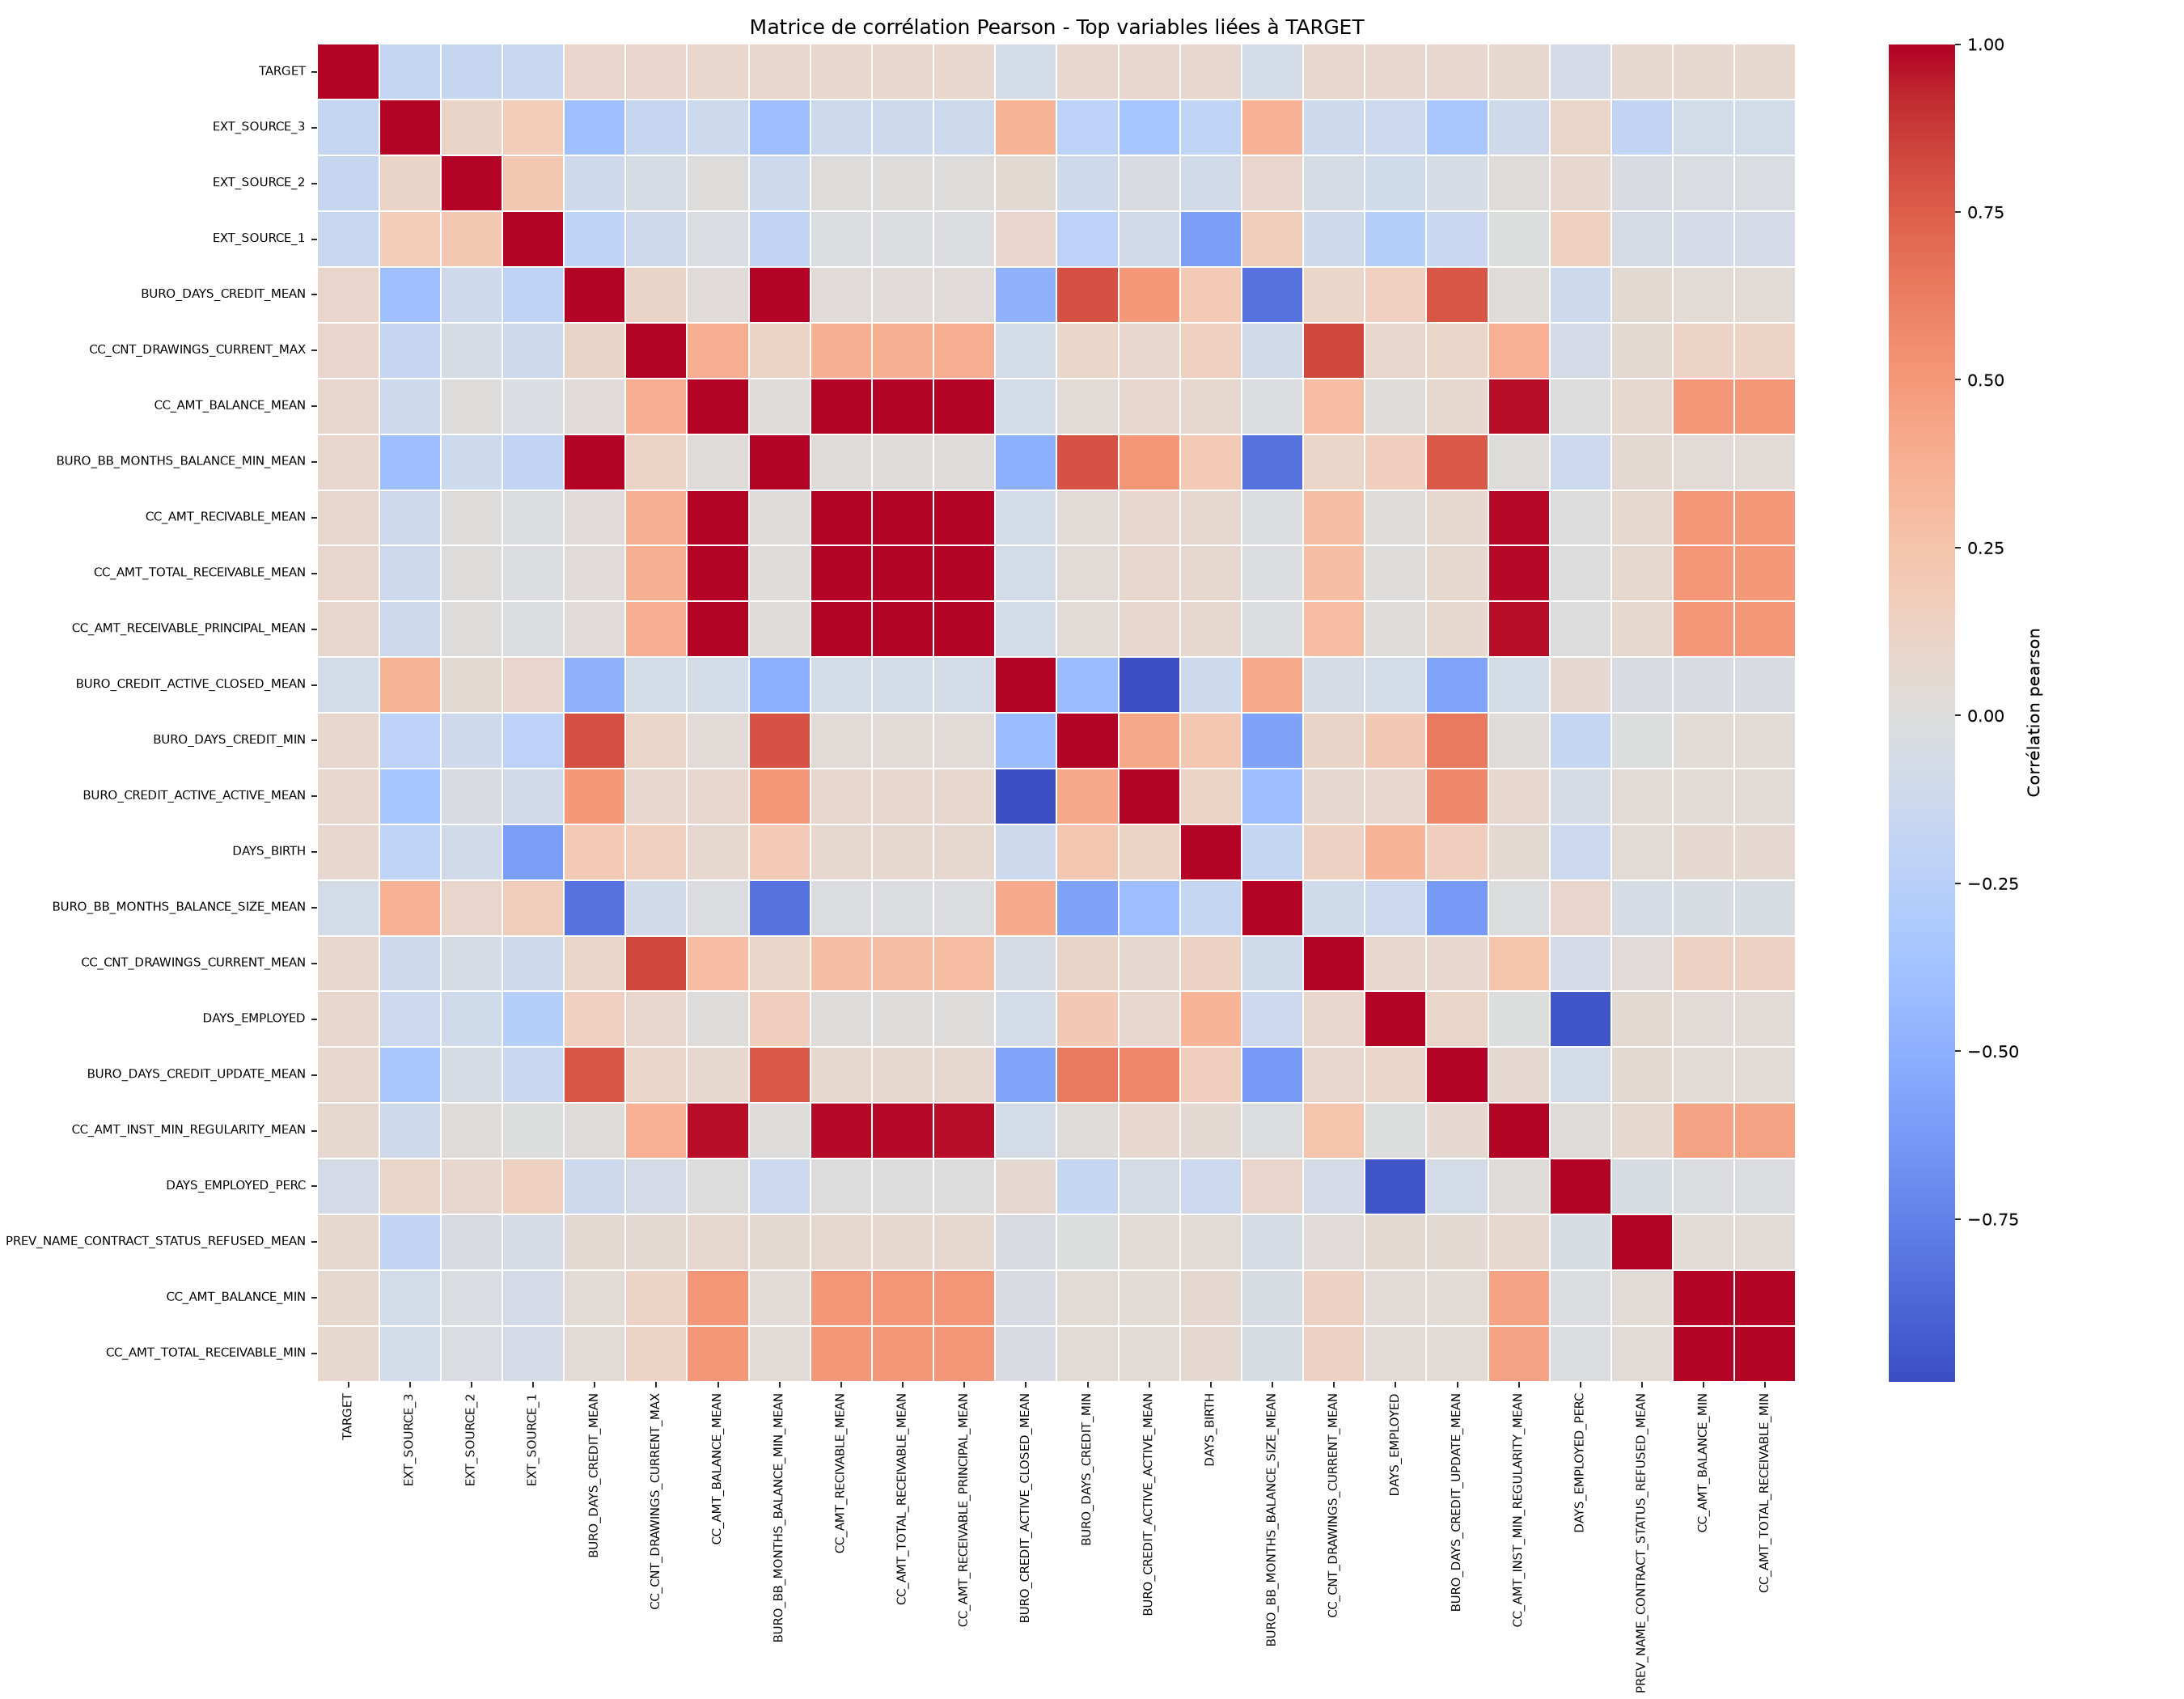

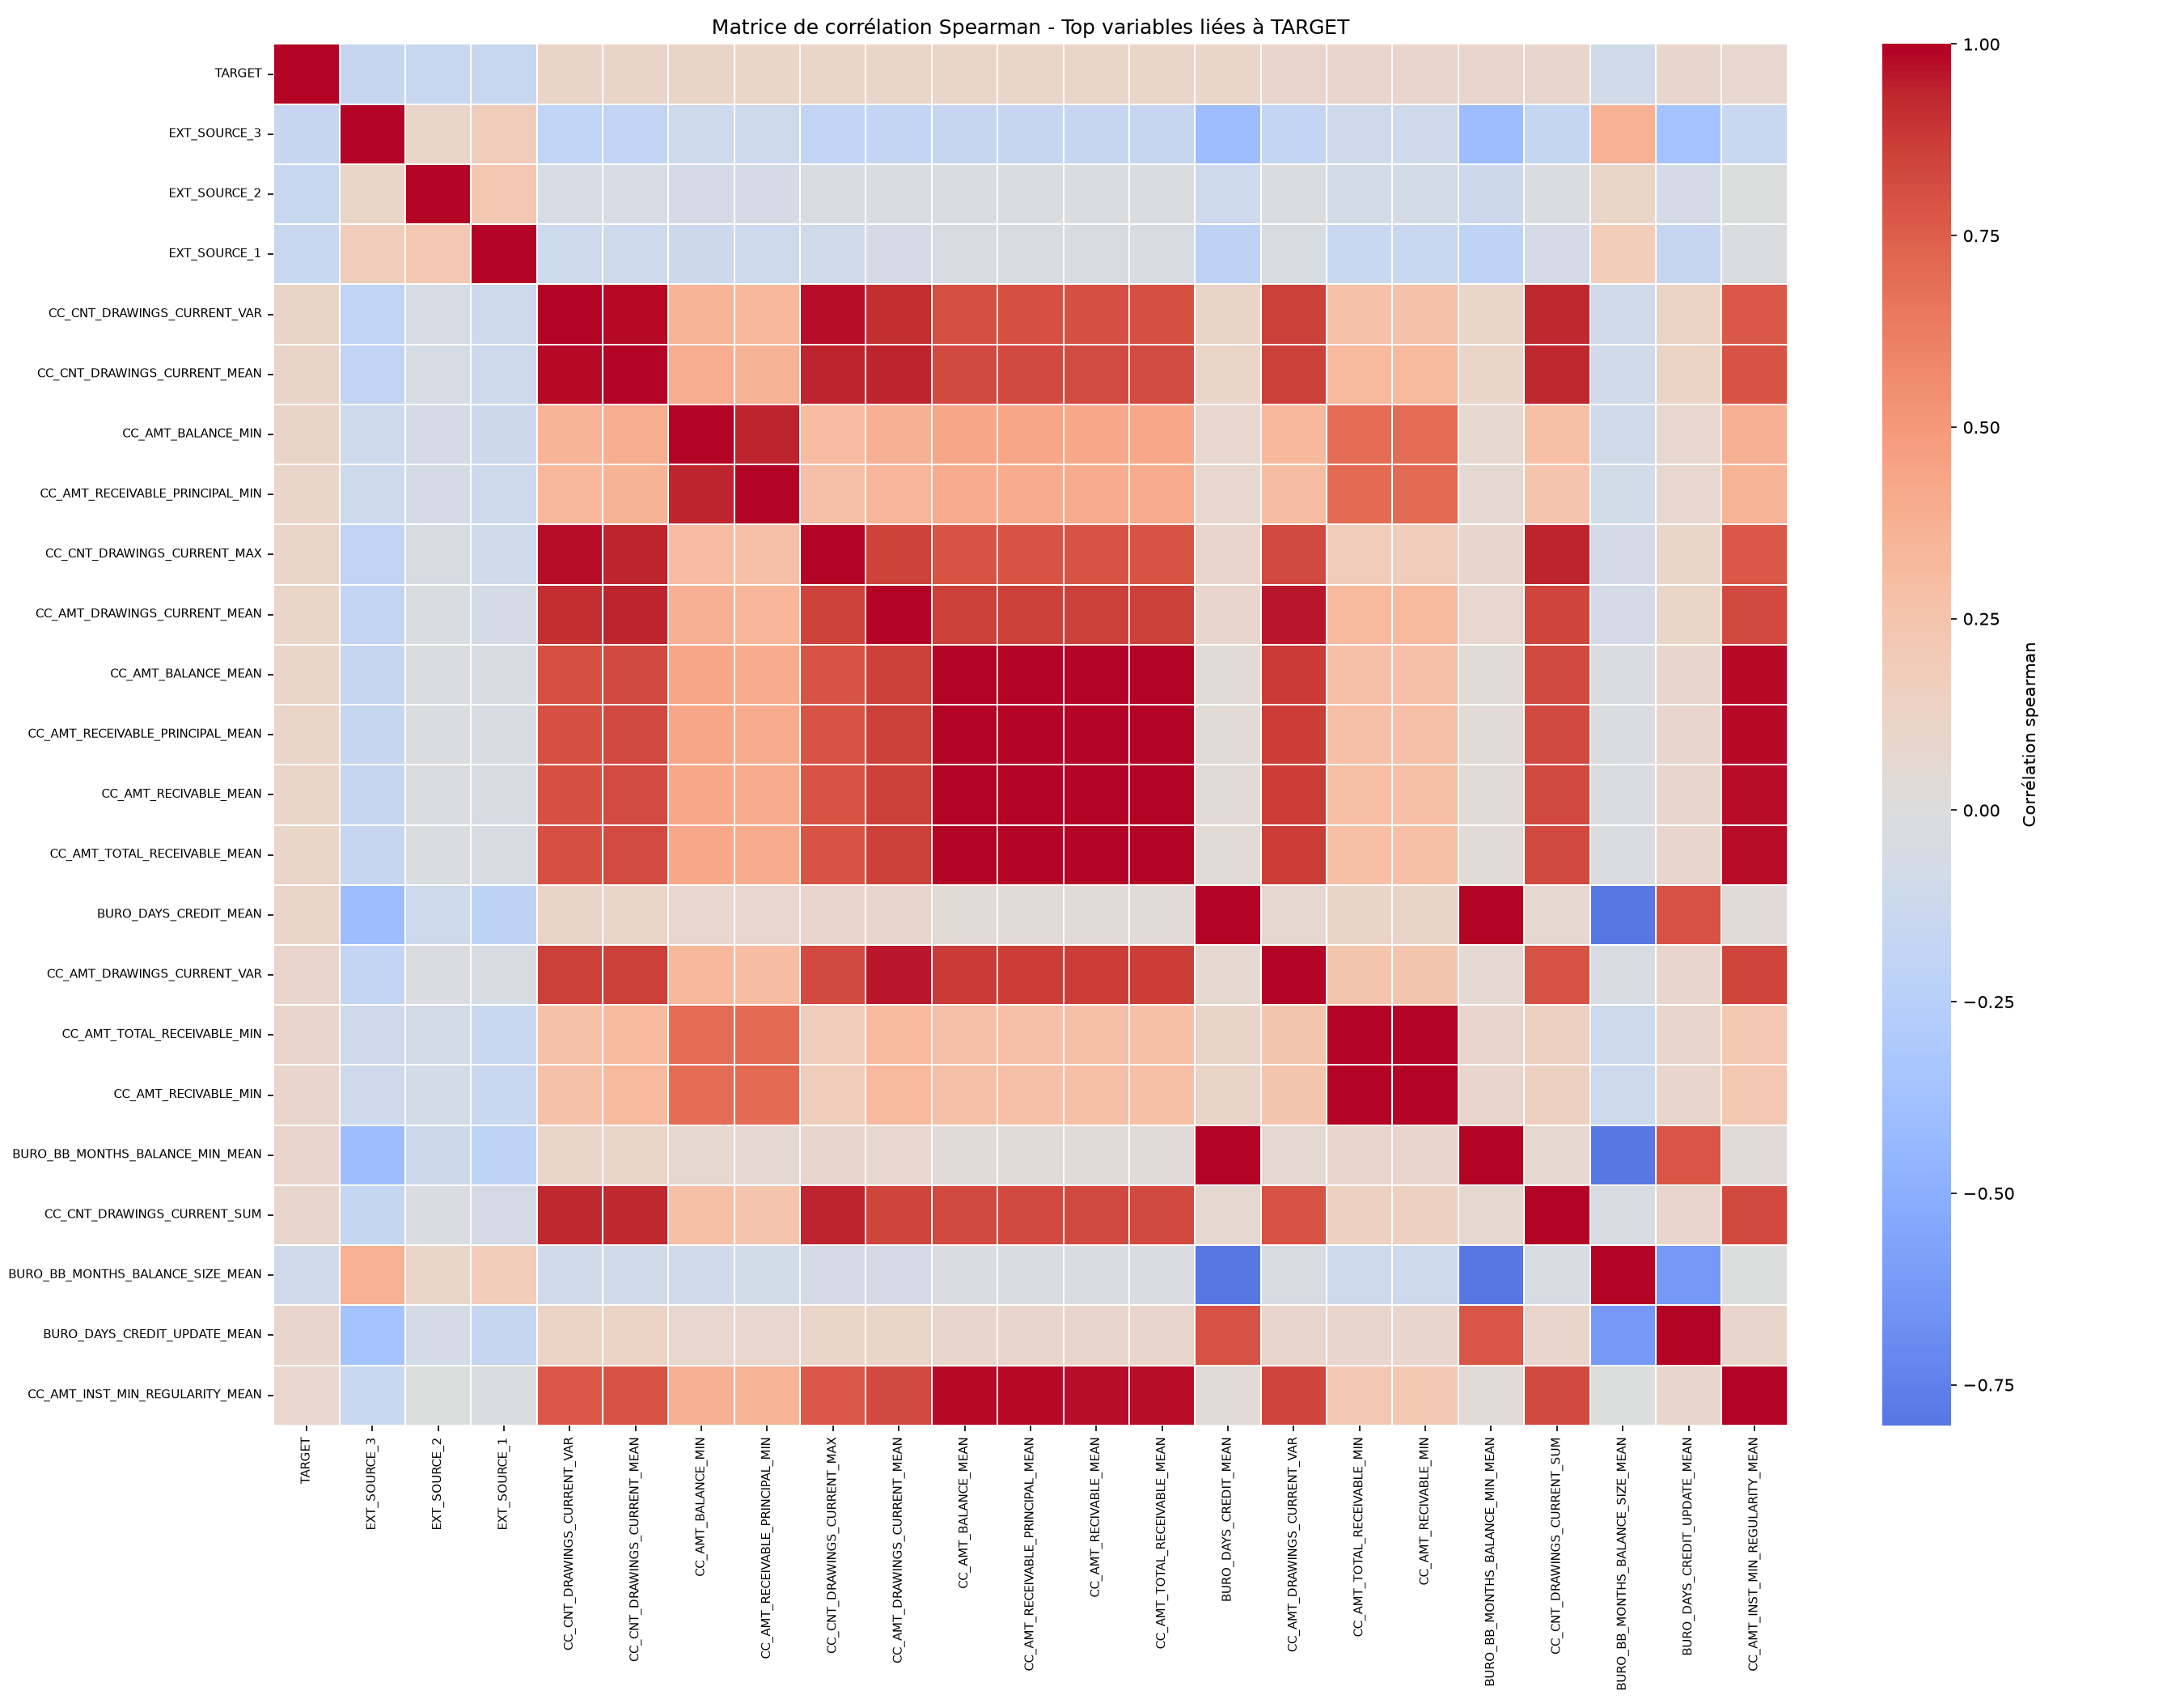

In [20]:
display(Image("../reports/figures/step1_correlation_matrix_pearson_top25.png"))
display(Image("../reports/figures/step1_correlation_matrix_spearman_top25.png"))

Les matrices de corrélation ont été calculées sur les variables les plus liées à `TARGET`, afin de conserver une visualisation lisible.

Certaines variables sont fortement corrélées entre elles, ce qui est attendu dans ce projet, car plusieurs agrégations décrivent des phénomènes proches. Ces corrélations seront surveillées lors de la modélisation, mais elles ne sont pas supprimées trop tôt afin de ne pas perdre d’information métier utile.

Les matrices de corrélation montrent que les variables `EXT_SOURCE_1`, `EXT_SOURCE_2` et `EXT_SOURCE_3` sont parmi les plus liées à la cible. Leur corrélation négative avec `TARGET` indique que plus ces scores externes sont élevés, plus le risque de défaut diminue.

On observe également des blocs de forte corrélation entre plusieurs variables issues de l’historique des cartes de crédit. Ces variables décrivent des informations proches, comme le solde moyen, les montants recevables ou le capital restant dû. Elles peuvent donc être partiellement redondantes.

Ces corrélations permettent d’identifier des relations importantes dans les données, mais elles ne prouvent pas une relation de causalité. Les variables fortement corrélées seront surveillées lors de la modélisation et de l’analyse d’importance des features.

In [21]:
processed_summary = pd.read_csv("../reports/data_quality/processed_dataset_summary.csv")
processed_summary

,dataset,rows,columns,total_missing_values,missing_rate,has_target
0,train,307507,697,44586677,0.2080,True
1,test,48744,696,5901017,0.1739,False


In [22]:
dropped_columns = pd.read_csv("../reports/data_quality/modeling_dropped_columns.csv")
dropped_columns.head(20)

,column,reason
0,CC_AMT_DRAWINGS_ATM_CURRENT_MAX,high_missing_or_constant
1,CC_AMT_DRAWINGS_ATM_CURRENT_MEAN,high_missing_or_constant
2,CC_AMT_DRAWINGS_ATM_CURRENT_MIN,high_missing_or_constant
3,CC_AMT_DRAWINGS_ATM_CURRENT_VAR,high_missing_or_constant
4,CC_AMT_DRAWINGS_OTHER_CURRENT_MAX,high_missing_or_constant
5,CC_AMT_DRAWINGS_OTHER_CURRENT_MEAN,high_missing_or_constant
6,CC_AMT_DRAWINGS_OTHER_CURRENT_MIN,high_missing_or_constant
7,CC_AMT_DRAWINGS_OTHER_CURRENT_VAR,high_missing_or_constant
8,CC_AMT_DRAWINGS_POS_CURRENT_MAX,high_missing_or_constant
9,CC_AMT_DRAWINGS_POS_CURRENT_MEAN,high_missing_or_constant


À l’issue de cette étape, un dataset de modélisation a été généré.

Le train contient la variable cible `TARGET`, tandis que le test conserve uniquement les variables explicatives. Les colonnes trop incomplètes ou constantes ont été supprimées de manière documentée.

Le dataset final est donc prêt pour l’étape suivante : l’entraînement d’un premier modèle baseline.